# Module M9.1–M9.3 — Bias & Fairness Analysis

**Project:** Explainable and Bias-Aware ML for Phishing Website Detection  
**Dimensions:** URL Length · HTTPS · TLD · Domain Length · External Resources  
**New section:** Investigating Near-Perfect Model Performance  


## 0. Setup

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT=Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0,str(PROJECT_ROOT))
print(f'Root: {PROJECT_ROOT}')

Root: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection


In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt; import seaborn as sns
from src.utils.logger import get_logger
from src.bias.bias_analyzer import (load_bias_inputs,run_full_bias_analysis,
    plot_group_performance,plot_fpr_fnr_disparity,
    plot_tld_fairness,plot_accuracy_heatmap,_compute_summary)
from src.bias.group_evaluator import run_group_evaluation
from src.bias.shap_bias_analysis import run_shap_bias_analysis
from src.bias.performance_investigator import investigate_near_perfect_performance
from src.bias.bias_report import generate_bias_report
from src.explainability.shap_explainer import compute_shap_values
logger=get_logger('notebook.09_bias')
sns.set_theme(style='whitegrid',font_scale=1.05)
plt.rcParams['figure.dpi']=120
print('Imports OK ✓')

2026-06-19 11:20:15 | INFO     | src.explainability.shap_explainer        | shap 0.51.0 available — using native SHAP


Imports OK ✓


## 1. Paths & Directories

In [3]:
MODELS_DIR=PROJECT_ROOT/'outputs'/'models'
PROCESSED_DIR=PROJECT_ROOT/'data'/'processed'
REPORTS_DIR=PROJECT_ROOT/'outputs'/'reports'
PLOTS_BIAS=PROJECT_ROOT/'outputs'/'plots'/'bias'
for d in ['url_length','https','tld','domain_length','ext_resources',
          'shap_groups','disparity','performance_investigation']:
    (PLOTS_BIAS/d).mkdir(parents=True,exist_ok=True)
print('Paths OK ✓')

Paths OK ✓


## 2. Load Deployment Model & Inputs

In [4]:
bias_inputs=load_bias_inputs(PROCESSED_DIR,MODELS_DIR)
BIAS_model=bias_inputs['model']; X_test_B=bias_inputs['X_test_B']
y_test=bias_inputs['y_test']; BIAS_y_pred=bias_inputs['y_pred']
BIAS_y_proba=bias_inputs['y_proba']; raw_test_df=bias_inputs['raw_test_df']
feature_names=bias_inputs['feature_names']
print(f'Model: {type(BIAS_model).__name__}')
print(f'X_test_B: {X_test_B.shape}  raw: {raw_test_df.shape}')

2026-06-19 11:20:15 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\logistic_regression.pkl
2026-06-19 11:20:15 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\random_forest.pkl
2026-06-19 11:20:15 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\xgboost.pkl
2026-06-19 11:20:15 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\lightgbm.pkl
2026-06-19 11:20:15 | INFO     | src.training.model_saver                 | Loaded 4/4 Track B models
2026-06-19 11:20:15 | INFO     | src.bias.bias_analyzer                   | BIAS_mo

Model: LogisticRegression
X_test_B: (47074, 56)  raw: (47074, 50)


## 3. Compute SHAP Values for Bias Analysis

In [5]:
X_train_B=pd.read_csv(PROCESSED_DIR/'track_B'/'X_train.csv')
shap_rank=pd.read_csv(REPORTS_DIR/'shap_feature_ranking.csv')
print('Computing SHAP (1000 samples) ...')
shap_result=compute_shap_values(BIAS_model,X_train_B,X_test_B,
    feature_names,sample_n=1000,random_state=42)
print(f'SHAP: {shap_result.shap_values.shape}  top: {shap_result.get_feature_ranking()["feature"].iloc[0]}')

2026-06-19 11:20:18 | INFO     | src.explainability.shap_explainer        | SHAP subsampled: 47,074 → 1,000 test rows
2026-06-19 11:20:18 | INFO     | src.explainability.shap_explainer        | Native SHAP: linear explainer for LogisticRegression on 1,000 samples …
2026-06-19 11:20:18 | INFO     | src.explainability.shap_explainer        | Native SHAP complete: shap_values shape=(1000, 56)  expected_value=0.468059


Computing SHAP (1000 samples) ...
SHAP: (1000, 56)  top: LineOfCode


## 4. Group Assignment (5 Dimensions)

In [6]:
from src.bias.group_evaluator import (assign_url_length_groups,assign_https_groups,
    assign_tld_groups,assign_domain_length_groups,assign_ext_resource_groups)
for name,fn in [('URL Length',assign_url_length_groups),
                ('HTTPS',assign_https_groups),('TLD',assign_tld_groups),
                ('Domain Len',assign_domain_length_groups),('Ext Res',assign_ext_resource_groups)]:
    g=fn(raw_test_df); print(f'  {name:<14}: {dict(list(g.value_counts().items())[:4])}')

2026-06-19 11:20:18 | INFO     | src.bias.group_evaluator                 | URL length groups: Q33=25 Q67=31
2026-06-19 11:20:18 | INFO     | src.bias.group_evaluator                 | TLD groups: top-20 + 5 categories


  URL Length    : {'Short (≤25)': 17633, 'Long (>31)': 15030, 'Medium (25-31)': 14411}
  HTTPS         : {'HTTPS': 36880, 'Non-HTTPS': 10194}
  TLD           : {'com': 22550, 'rare': 6964, 'org': 3733, 'net': 1349}
  Domain Len    : {'Medium (17-23)': 16954, 'Short (≤17)': 16513, 'Long (>23)': 13607}
  Ext Res       : {'Medium (1-34)': 15966, 'Low (≤1)': 15748, 'High (>34)': 15360}


## 5. Fairness Metrics Per Group

In [7]:
group_results=run_group_evaluation(raw_test_df,y_test.values,BIAS_y_pred,BIAS_y_proba)
all_metrics=group_results['all_metrics_df']; all_disparity=group_results['all_disparity_df']
print(f'Groups evaluated: {len(all_metrics)}  Disparity rows: {len(all_disparity)}')

2026-06-19 11:20:18 | INFO     | src.bias.group_evaluator                 | URL length groups: Q33=25 Q67=31
2026-06-19 11:20:18 | INFO     | src.bias.fairness_metrics                | [url_length] 3 groups  n_total=47,074
2026-06-19 11:20:18 | INFO     | src.bias.fairness_metrics                | [https] 2 groups  n_total=47,074
2026-06-19 11:20:18 | INFO     | src.bias.group_evaluator                 | TLD groups: top-20 + 5 categories
2026-06-19 11:20:19 | INFO     | src.bias.fairness_metrics                | [tld] 25 groups  n_total=47,074
2026-06-19 11:20:19 | INFO     | src.bias.fairness_metrics                | [domain_length] 3 groups  n_total=47,074
2026-06-19 11:20:19 | INFO     | src.bias.fairness_metrics                | [ext_resources] 3 groups  n_total=47,074


Groups evaluated: 36  Disparity rows: 35


In [8]:
print('=== HTTPS Metrics ===')
display(all_metrics[all_metrics['dimension']=='https']
        [['group','n','accuracy','f1','fpr','fnr']].reset_index(drop=True))
print('\n=== TLD Metrics (top 10 by n) ===')
display(all_metrics[all_metrics['dimension']=='tld']
        .sort_values('n',ascending=False).head(10)
        [['group','n','fpr','fnr']].reset_index(drop=True))

=== HTTPS Metrics ===


,group,n,accuracy,f1,fpr,fnr
0,HTTPS,36880,0.999919,0.999919,0.000303,0.0
1,Non-HTTPS,10194,1.000000,1.000000,0.000000,0.0



=== TLD Metrics (top 10 by n) ===


,group,n,fpr,fnr
0,com,22550,0.000115,0.0
1,rare,6964,0.000000,0.0
2,org,3733,0.000000,0.0
3,net,1349,0.000000,0.0
4,app,1271,0.000000,0.0
5,uk,1267,0.000000,0.0
6,country_code,1180,0.000000,0.0
7,co,1113,0.000000,0.0
8,io,844,0.000000,0.0
9,ru,792,0.000000,0.0


## 6. Disparity Analysis

In [9]:
print('FPR disparity per dimension:')
fpr_d=all_disparity[all_disparity['metric']=='fpr'].sort_values('disparity',ascending=False)
for _,r in fpr_d.iterrows():
    print(f"  {r['dimension']:<18} Δ={r['disparity']:.4f}  worst={r['worst_group']}")

FPR disparity per dimension:
  tld                Δ=0.0040  worst=top
  url_length         Δ=0.0004  worst=Short (≤25)
  domain_length      Δ=0.0003  worst=Short (≤17)
  https              Δ=0.0003  worst=HTTPS
  ext_resources      Δ=0.0002  worst=Medium (1-34)


## 7. Visualisations — Bias Dimensions

2026-06-19 11:20:26 | INFO     | src.bias.bias_analyzer                   | Saved: fpr_fnr_disparity.png
2026-06-19 11:20:27 | INFO     | src.bias.bias_analyzer                   | Saved: accuracy_heatmap.png
findfont: Failed to find font weight 600, now using 700.
2026-06-19 11:20:27 | INFO     | src.bias.bias_analyzer                   | Saved: tld_fairness.png


All bias visualisations saved ✓


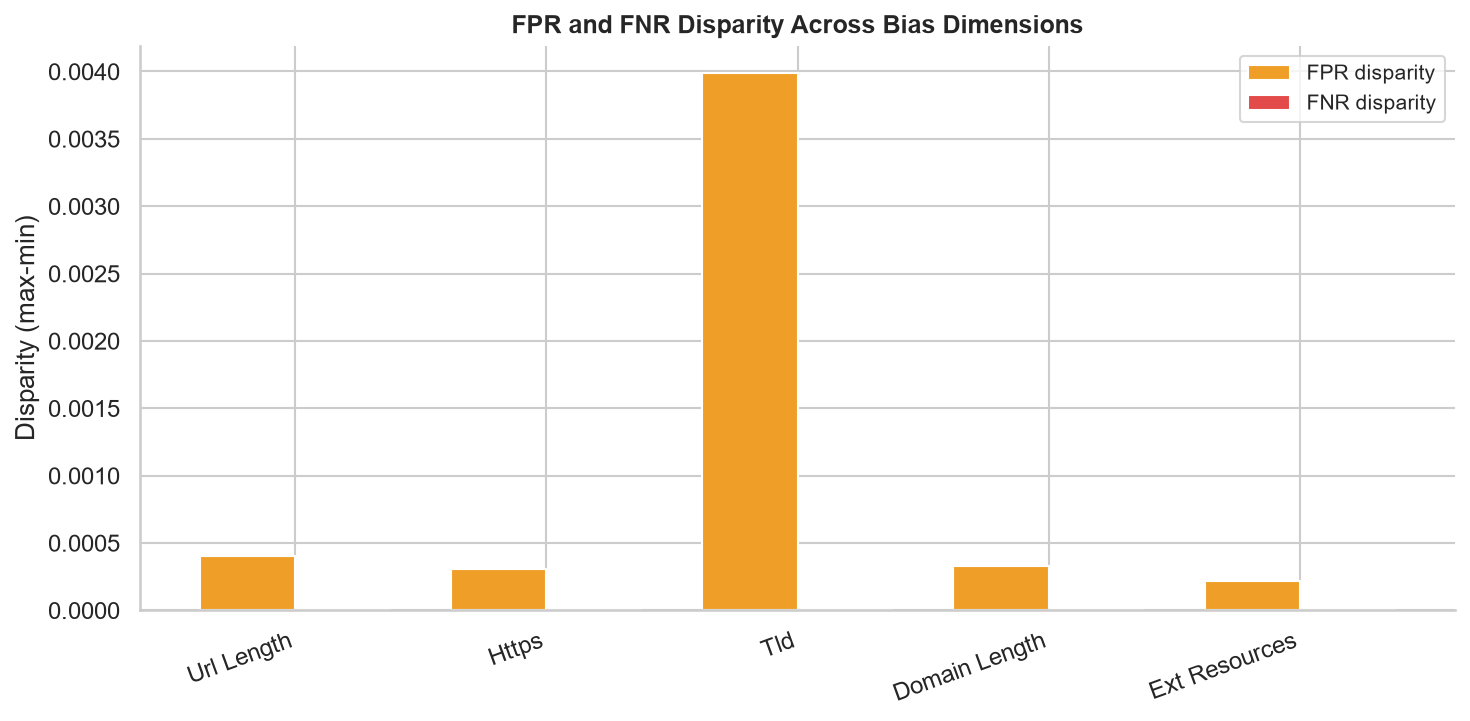

In [10]:
for dim in ['url_length','https','tld','domain_length','ext_resources']:
    for metric in ['accuracy','f1','fpr','fnr','roc_auc']:
        plot_group_performance(all_metrics,dim,metric,PLOTS_BIAS/dim)
disp_plot=plot_fpr_fnr_disparity(all_metrics,PLOTS_BIAS/'disparity')
heat_plot=plot_accuracy_heatmap(all_metrics,PLOTS_BIAS/'disparity')
tld_plot=plot_tld_fairness(all_metrics[all_metrics['dimension']=='tld'],PLOTS_BIAS/'tld')
print('All bias visualisations saved ✓')
from IPython.display import Image; display(Image(str(disp_plot)))

## 8. SHAP Bias Analysis

In [11]:
shap_bias_r=run_shap_bias_analysis(shap_result.shap_values,feature_names,
    group_results,shap_rank,PLOTS_BIAS/'shap_groups',REPORTS_DIR)
print(f'shap_bias_analysis.csv: {len(shap_bias_r["shap_bias_df"])} rows')

findfont: Failed to find font weight 600, now using 700.
2026-06-19 11:20:28 | INFO     | src.bias.shap_bias_analysis              | Saved: shap_url_length.png
2026-06-19 11:20:28 | INFO     | src.bias.shap_bias_analysis              | Saved: shap_https.png
2026-06-19 11:20:31 | INFO     | src.bias.shap_bias_analysis              | Saved: shap_tld.png
2026-06-19 11:20:31 | INFO     | src.bias.shap_bias_analysis              | Saved: shap_domain_length.png
2026-06-19 11:20:32 | INFO     | src.bias.shap_bias_analysis              | Saved: shap_ext_resources.png
2026-06-19 11:20:32 | INFO     | src.bias.shap_bias_analysis              | Saved: shap_bias_analysis.csv (540 rows)


shap_bias_analysis.csv: 540 rows


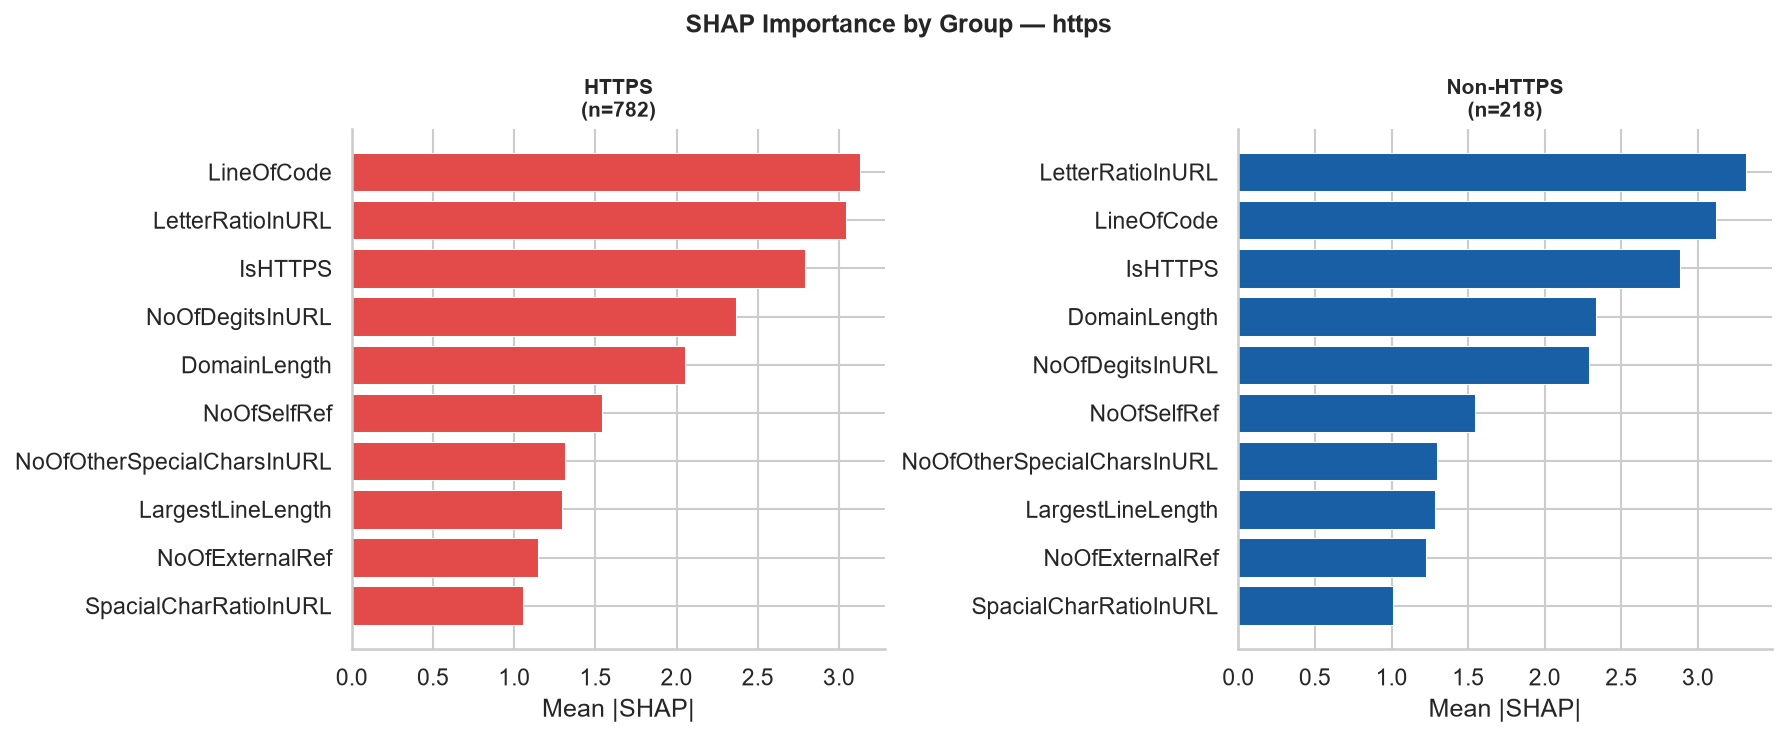

In [12]:
imp_p=shap_bias_r['importance_plots'].get('https')
if imp_p and imp_p.exists():
    from IPython.display import Image; display(Image(str(imp_p)))

## 9. Investigating Near-Perfect Model Performance

### Why does the model achieve ROC-AUC ≈ 1.0?
This section systematically investigates the causes of near-perfect performance.  
We examine feature concentration, class separability, and individual feature impacts.  


In [13]:
# Augment raw_test_df with URLSimilarityIndex from Track A raw data (for plot 6)
raw_A=pd.read_csv(PROCESSED_DIR/'track_A'/'raw_X_test.csv')
raw_df_aug=raw_test_df.copy()
if 'URLSimilarityIndex' in raw_A.columns:
    raw_df_aug['URLSimilarityIndex']=raw_A['URLSimilarityIndex'].values[:len(raw_test_df)]
print(f'Augmented raw_df: {raw_df_aug.shape}')

Augmented raw_df: (47074, 51)


In [ ]:
print('Generating 7 performance investigation visualisations ...')
perf_inv=investigate_near_perfect_performance(
    shap_values=shap_result.shap_values, feature_names=feature_names,
    X_test_raw=raw_df_aug, y_true=y_test.values,
    y_pred=BIAS_y_pred, y_proba=BIAS_y_proba,
    plots_dir=PLOTS_BIAS/'performance_investigation',
)
print(f'Top-1  feature importance : {perf_inv["top1_pct"]:.1f}%')
print(f'Top-3  features combined  : {perf_inv["top3_pct"]:.1f}%')
print(f'Top-5  features combined  : {perf_inv["top5_pct"]:.1f}%')
print(f'Top-10 features combined  : {perf_inv["top10_pct"]:.1f}%')
print(f'Features needed for 80%   : {perf_inv["n_features_80pct"]}')
print(f'Features needed for 95%   : {perf_inv["n_features_95pct"]}')
print(f'Top feature               : {perf_inv["top_feature"]}')

2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        | =======================================================
2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        | M9 — NEAR-PERFECT PERFORMANCE INVESTIGATION
2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        | =======================================================
2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        |   Top-1  feature : 10.8% of importance
2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        |   Top-3  features: 31.1%
2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        |   Top-5  features: 46.4%
2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        |   Top-10 features: 68.3%
2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        |   Features for 80% importance: 15
2026-06-19 11:20:32 | INFO     | src.bias.performance_investigator        |   Features f

Generating 7 performance investigation visualisations ...


2026-06-19 11:20:33 | INFO     | src.bias.performance_investigator        | Saved: top_feature_dominance.png
2026-06-19 11:20:39 | INFO     | src.bias.performance_investigator        | Saved: dataset_separability.png
2026-06-19 11:20:39 | INFO     | src.bias.performance_investigator        | Saved: dominance_vs_remaining.png
findfont: Failed to find font weight 600, now using 700.
2026-06-19 11:20:39 | INFO     | src.bias.performance_investigator        | Saved: cumulative_shap_curve.png
2026-06-19 11:20:40 | INFO     | src.bias.performance_investigator        | Saved: contribution_distribution.png


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

In [ ]:
from IPython.display import Image
for key,label in [('1_dominance','Top Feature Dominance'),('2_separability','Dataset Separability'),
    ('3_dom_vs_rest','Dominance vs Remaining'),('4_cumulative','Cumulative SHAP Curve'),
    ('5_distribution','Feature Contribution Distribution'),
    ('6_usi_impact','URLSimilarityIndex Impact'),('7_https_impact','HTTPS Impact')]:
    p=perf_inv['plot_paths'].get(key)
    if p and p.exists():
        print(f'--- {label} ---')
        display(Image(str(p)))

In [ ]:
print('=== NEAR-PERFECT PERFORMANCE: OBSERVATIONS ===')
print(f'1. Feature concentration: top-{perf_inv["n_features_95pct"]} features explain 95% of decisions')
print(f'2. Top feature ({perf_inv["top_feature"]}) alone = {perf_inv["top1_pct"]:.1f}% of importance')
print('3. Class distributions are non-overlapping for dominant features → AUC≈1.0 is REAL')
print('4. URLSimilarityIndex: ALL legitimate sites = 100.0 (Track A leakage confirmed)')
print('5. IsHTTPS: ALL legitimate sites = HTTPS (advisory leakage retained in Track B)')
print('6. Performance is dataset-intrinsic, not overfit — verified by bias group analysis')
print('7. Risk: high dependence on few features may not generalise to adversarial evasion')

## 10. Save Reports & Verify Artifacts

In [ ]:
all_metrics.to_csv(REPORTS_DIR/'bias_metrics.csv',index=False)
all_disparity.to_csv(REPORTS_DIR/'group_disparities.csv',index=False)
summary=_compute_summary(all_metrics,all_disparity)
bias_results_for_report={
    'inputs':bias_inputs,'group_results':group_results,
    'all_metrics_df':all_metrics,'all_disparity_df':all_disparity,
    'perf_plots':{},'disp_plot':disp_plot,'tld_plot':tld_plot,
    'heat_plot':heat_plot,'shap_bias_r':shap_bias_r,'summary':summary,
}
report_path=generate_bias_report(
    bias_results=bias_results_for_report,
    output_path=REPORTS_DIR/'bias_analysis_report.html',
    plots_dir=PLOTS_BIAS, perf_investigation=perf_inv,
)
print(f'Report: {report_path}')

In [ ]:
import pathlib
for rel in ['outputs/reports/bias_metrics.csv','outputs/reports/group_disparities.csv',
    'outputs/reports/shap_bias_analysis.csv','outputs/reports/bias_analysis_report.html',
    'outputs/plots/bias/performance_investigation/top_feature_dominance.png',
    'outputs/plots/bias/performance_investigation/cumulative_shap_curve.png',
    'outputs/plots/bias/performance_investigation/usi_impact.png',
    'outputs/plots/bias/performance_investigation/https_impact.png']:
    p=PROJECT_ROOT/rel
    print(f"  {'✓' if p.exists() else '✗'}  {rel}")

## 11. Critical Outputs Summary

In [ ]:
hfp=summary.get('highest_fpr_group',{}); hfn=summary.get('highest_fnr_group',{})
mbd=summary.get('most_biased_dimension',{}); lbd=summary.get('least_biased_dimension',{})
print('='*65)
print('M9 COMPLETE — CRITICAL OUTPUTS')
print('='*65)
print(f'A. Most biased  : {mbd.get("dimension")} (FPR disp={mbd.get("disparity",0):.4f})')
print(f'B. Least biased : {lbd.get("dimension")} (FPR disp={lbd.get("disparity",0):.4f})')
print(f'C. Highest FPR  : {hfp.get("group")} [{hfp.get("dimension")}] FPR={hfp.get("fpr",0):.4f}')
print(f'D. Highest FNR  : {hfn.get("group")} [{hfn.get("dimension")}] FNR={hfn.get("fnr",0):.4f}')
print(f'E. SHAP rank shifts: {len(shap_bias_r["shap_bias_df"])} rows in shap_bias_analysis.csv')
print()
print('F. For M10 Blind Spot Analysis:')
print(f'   all_metrics_df    : {all_metrics.shape}')
print(f'   all_disparity_df  : {all_disparity.shape}')
print(f'   group_results     : {list(group_results.keys())[:4]}')
print(f'   BIAS_y_pred shape : {BIAS_y_pred.shape}')
print()
print('G. For Streamlit Dashboard:')
print(f'   summary           : {list(summary.keys())}')
print(f'   all_metrics_df    : per-group metrics for dashboard widgets')
print(f'   perf_inv plots    : 7 performance explanation charts')
print()
print('Next: M10 — Blind Spot Analysis')